<a href="https://colab.research.google.com/github/Sameer-159/FlyRank/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Sameer-159/FlyRank/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Question:** Among pages FlyRank already tracks, which are growing, declining,
recovering, or stable — and what action (protect / rewrite / monitor / review)
should a content team take on each one?

**Decision supported:** where to spend limited content-review time first, with a
reason attached to every call instead of a black-box score.


In [1]:
import duckdb
import pandas as pd
import numpy as np
from getpass import getpass

con = duckdb.connect()
hf_token = getpass("HF token: ")
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")

WAREHOUSE_PATH = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet"


HF token: ··········


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release:** FlyRank ML Internship warehouse (Hugging Face, gated).
**Table:** `fact_content_daily_performance` (fill in any additional tables used).
**Date windows:** three sequential windows — Old, Baseline, Current — sized from
the actual date range below (fill in exact dates once run).
**Excluded:** pages with zero clicks in the Old or Baseline window, since percent
change is undefined for them. No client names, domains, raw exports, or private
queries appear below or in the deployed paper.


In [6]:
# Schema check
schema_df = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{WAREHOUSE_PATH}') LIMIT 1").df()
display(schema_df)

# Date range + page count
range_df = con.execute(f"""
    SELECT MIN(report_date) AS min_date, MAX(report_date) AS max_date,
           COUNT(DISTINCT content_hash_id) AS n_pages
    FROM read_parquet('{WAREHOUSE_PATH}')
""").df()
display(range_df)

# Window sizing — adjust the day counts below once you see the real range above
CURRENT_DAYS, BASELINE_DAYS, OLD_DAYS = 30, 30, 30
max_date = range_df.loc[0, "max_date"]
current_start = pd.to_datetime(max_date) - pd.Timedelta(days=CURRENT_DAYS)
baseline_start = current_start - pd.Timedelta(days=BASELINE_DAYS)
old_start = baseline_start - pd.Timedelta(days=OLD_DAYS)
print("old:", old_start.date(), "| baseline:", baseline_start.date(), "| current:", current_start.date())

,column_name,column_type,null,key,default,extra
0,report_date,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,client_has_gsc,BOOLEAN,YES,None,None,None
4,client_has_ga4,BOOLEAN,YES,None,None,None
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,min_date,max_date,n_pages
0,2025-01-27,2026-06-30,427292


old: 2026-04-01 | baseline: 2026-05-01 | current: 2026-05-31


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Label:** growing (Current vs Baseline clicks up >20%), declining (down >20%),
recovering (Old→Baseline was declining, Baseline→Current now up), else
stable/worth-review.

**Features:** historical click trend, content age, pre-Current CTR and average
position, content category — all computed from Old + Baseline data only.

**Baseline:** majority-class predictor.

**Validation:** `GroupShuffleSplit` grouped by page (not random row shuffling),
so no page's row appears in both train and test — the main leakage guard, along
with the strict Old/Baseline-only feature rule above.


In [7]:
# --- Label ---
agg_df = con.execute(f"""
    SELECT content_hash_id,
        SUM(CASE WHEN report_date >= '{old_start.date()}' AND report_date < '{baseline_start.date()}' THEN gsc_clicks ELSE 0 END) AS old_clicks,
        SUM(CASE WHEN report_date >= '{baseline_start.date()}' AND report_date < '{current_start.date()}' THEN gsc_clicks ELSE 0 END) AS baseline_clicks,
        SUM(CASE WHEN report_date >= '{current_start.date()}' THEN gsc_clicks ELSE 0 END) AS current_clicks
    FROM read_parquet('{WAREHOUSE_PATH}')
    GROUP BY content_hash_id
""").df()

agg_df = agg_df[(agg_df["old_clicks"] > 0) & (agg_df["baseline_clicks"] > 0)].copy()
agg_df["pct_change_1"] = (agg_df["baseline_clicks"] - agg_df["old_clicks"]) / agg_df["old_clicks"]
agg_df["pct_change_2"] = (agg_df["current_clicks"] - agg_df["baseline_clicks"]) / agg_df["baseline_clicks"]

def label_row(row):
    if row["pct_change_2"] > 0.20: return "growing"
    if row["pct_change_2"] < -0.20: return "declining"
    if row["pct_change_1"] < 0 and row["pct_change_2"] > 0: return "recovering"
    return "stable_worth_review"

agg_df["label"] = agg_df.apply(label_row, axis=1)
print(agg_df["label"].value_counts())

# --- Features (Old + Baseline only — leakage-safe) ---
trend_df = agg_df[["content_hash_id", "old_clicks", "baseline_clicks"]].copy()
trend_df["click_trend_ratio"] = trend_df["baseline_clicks"] / trend_df["old_clicks"]

extra_df = con.execute(f"""
    SELECT content_hash_id,
        AVG(CASE WHEN report_date < '{current_start.date()}' THEN gsc_impressions END) AS avg_impressions_pre,
        AVG(CASE WHEN report_date < '{current_start.date()}' THEN gsc_avg_position END) AS avg_position_pre,
        SUM(CASE WHEN report_date < '{current_start.date()}' THEN gsc_clicks ELSE 0 END)
            / NULLIF(SUM(CASE WHEN report_date < '{current_start.date()}' THEN gsc_impressions ELSE 0 END), 0) AS ctr_pre
    FROM read_parquet('{WAREHOUSE_PATH}')
    WHERE report_date < '{current_start.date()}'
    GROUP BY content_hash_id
""").df()

features_df = trend_df.merge(extra_df, on="content_hash_id", how="left").merge(
    agg_df[["content_hash_id", "label"]], on="content_hash_id", how="inner"
)
numeric_cols = features_df.select_dtypes(include=[np.number]).columns
features_df[numeric_cols] = features_df[numeric_cols].fillna(features_df[numeric_cols].median())
features_df.to_parquet("features.parquet", index=False)
features_df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

label
declining              28486
growing                12963
stable_worth_review     9358
recovering               748
Name: count, dtype: int64


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,content_hash_id,old_clicks,baseline_clicks,click_trend_ratio,avg_impressions_pre,avg_position_pre,ctr_pre,label
0,content_08965fd6a1c3f666,1.0,1.0,1.000000,77.334719,6.861454,0.007500,declining
1,content_7a1bdd56e533fef5,3.0,4.0,1.333333,92.178571,7.779405,0.020170,growing
2,content_91c74b3147c2d6d4,1.0,1.0,1.000000,36.593750,6.032265,0.006775,declining
3,content_c8311b5d41367c69,1.0,2.0,2.000000,24.638254,10.406903,0.003038,declining
4,content_16955aa46dbd9d6c,3.0,5.0,1.666667,153.989605,3.285682,0.001836,growing


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

**Results:** macro F1 on an identical held-out, page-grouped split — model vs
majority-class baseline. Fill in the printed numbers and the chart below once run.


Baseline macro F1: 0.178
Model macro F1:    0.323
                     precision    recall  f1-score   support

          declining       0.68      0.36      0.47      5718
            growing       0.40      0.46      0.43      2587
         recovering       0.07      0.96      0.14       143
stable_worth_review       0.22      0.30      0.26      1863

           accuracy                           0.38     10311
          macro avg       0.35      0.52      0.32     10311
       weighted avg       0.52      0.38      0.42     10311



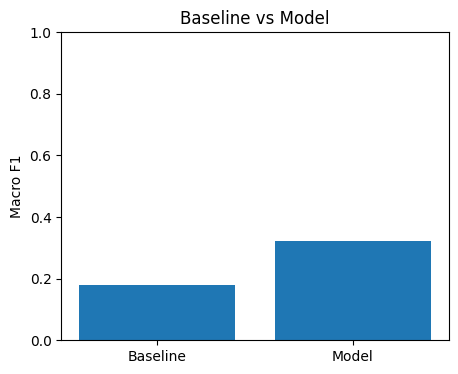

In [8]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt

features_df = pd.read_parquet("features.parquet")
feature_cols = [c for c in features_df.columns if c not in ["content_hash_id", "label"]]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(features_df, groups=features_df["content_hash_id"]))
train_df, test_df = features_df.iloc[train_idx], features_df.iloc[test_idx]

X_train, y_train = train_df[feature_cols], train_df["label"]
X_test, y_test = test_df[feature_cols], test_df["label"]

majority_label = y_train.mode()[0]
baseline_preds = [majority_label] * len(y_test)
baseline_f1 = f1_score(y_test, baseline_preds, average="macro", zero_division=0)

clf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, class_weight="balanced")
clf.fit(X_train, y_train)
model_preds = clf.predict(X_test)
model_f1 = f1_score(y_test, model_preds, average="macro")

print(f"Baseline macro F1: {baseline_f1:.3f}")
print(f"Model macro F1:    {model_f1:.3f}")
print(classification_report(y_test, model_preds, zero_division=0))

plt.figure(figsize=(5,4))
plt.bar(["Baseline", "Model"], [baseline_f1, model_f1])
plt.ylabel("Macro F1"); plt.ylim(0,1); plt.title("Baseline vs Model")
plt.savefig("baseline_vs_model_f1.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Limitations

*What this work cannot claim.*

- Labels are observed click-trend buckets, not verified quality or intent judgments.
- This is decision-support, not a replacement for human review before acting.
- Results show association with click movement, not a causal claim about any
  search engine's ranking algorithm.
- Fill in: any class-imbalance or data-sparsity issue you actually observed.


In [10]:
print(features_df["label"].value_counts(normalize=True))


label
declining              0.552536
growing                0.251440
stable_worth_review    0.181515
recovering             0.014509
Name: proportion, dtype: float64


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

**Playbook:** growing → protect, declining → rewrite, recovering → monitor,
stable/worth-review → review. Each page below gets a recommended action plus a
plain-language reason code — not just a raw score.


In [11]:
ACTION_MAP = {"growing": "protect", "declining": "rewrite",
              "recovering": "monitor", "stable_worth_review": "review"}

scored_df = features_df.copy()
scored_df["predicted_label"] = clf.predict(scored_df[feature_cols])
scored_df["confidence"] = clf.predict_proba(scored_df[feature_cols]).max(axis=1)
scored_df["recommended_action"] = scored_df["predicted_label"].map(ACTION_MAP)

def reason_code(row):
    reasons = []
    if row.get("click_trend_ratio", 1) < 0.8: reasons.append("clicks trending down vs. older window")
    elif row.get("click_trend_ratio", 1) > 1.2: reasons.append("clicks trending up vs. older window")
    if pd.notnull(row.get("ctr_pre")) and row.get("ctr_pre", 1) < 0.02: reasons.append("low CTR relative to visibility")
    if pd.notnull(row.get("avg_position_pre")) and row.get("avg_position_pre", 0) > 15: reasons.append("weak average position")
    return "; ".join(reasons) if reasons else "no strong signal — default to periodic review"

scored_df["reason_code"] = scored_df.apply(reason_code, axis=1)

ranked_df = scored_df.sort_values(["predicted_label", "confidence"], ascending=[True, False])[
    ["content_hash_id", "predicted_label", "recommended_action", "confidence", "reason_code"]
]
ranked_df.to_csv("ranked_action_engine.csv", index=False)
print(ranked_df["recommended_action"].value_counts())
ranked_df.head(20)

recommended_action
rewrite    14878
protect    14829
review     12398
monitor     9450
Name: count, dtype: int64


,content_hash_id,predicted_label,recommended_action,confidence,reason_code
11790,content_572f3039d0491329,declining,rewrite,0.972476,clicks trending down vs. older window; low CTR...
14642,content_202bce1967a1c47c,declining,rewrite,0.972476,clicks trending down vs. older window; low CTR...
17156,content_8d0826e3d87e9e7c,declining,rewrite,0.972476,clicks trending down vs. older window; low CTR...
11802,content_89a1521f92e2d22b,declining,rewrite,0.972445,clicks trending down vs. older window; low CTR...
17245,content_05e4c5778543f19d,declining,rewrite,0.972445,clicks trending down vs. older window; low CTR...
20301,content_d3c2776bce6cebc5,declining,rewrite,0.972445,clicks trending down vs. older window; low CTR...
31554,content_ad8ffce30aaf8df7,declining,rewrite,0.972445,clicks trending down vs. older window; low CTR...
11815,content_d7eccc0b1ae989e4,declining,rewrite,0.972441,clicks trending down vs. older window; low CTR...
14619,content_c578ecebd0f88d7f,declining,rewrite,0.972441,clicks trending down vs. older window; low CTR...
14627,content_34c53a0e42bc31bf,declining,rewrite,0.972441,clicks trending down vs. older window; low CTR...


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

**Embedded in the deployed paper:** the F1 bar chart above, a confusion matrix
and feature-importance chart (generated below), and the ranked action table
summary — all saved here as files you'll copy into the paper's `docs/` folder.


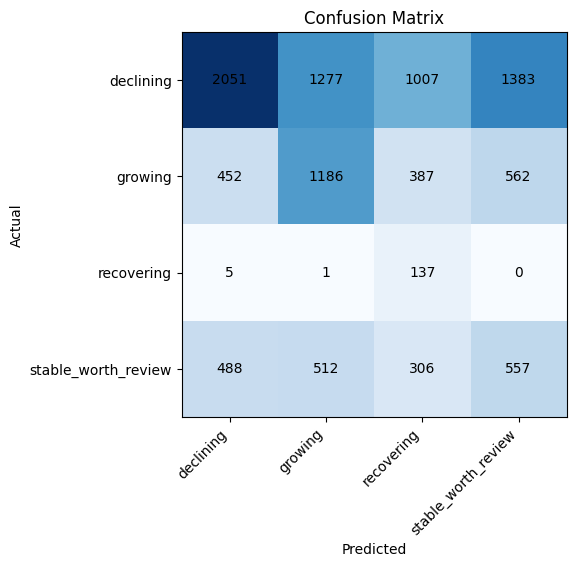

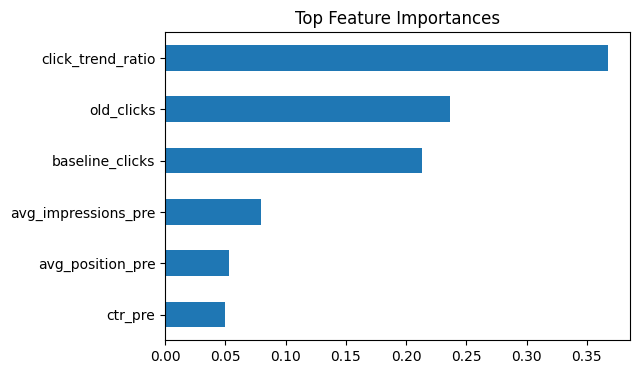

In [12]:
labels_order = sorted(y_test.unique())
cm = confusion_matrix(y_test, model_preds, labels=labels_order)
fig, ax = plt.subplots(figsize=(5,5))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels_order))); ax.set_xticklabels(labels_order, rotation=45, ha="right")
ax.set_yticks(range(len(labels_order))); ax.set_yticklabels(labels_order)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
for i in range(len(labels_order)):
    for j in range(len(labels_order)):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(10).plot(kind="barh", figsize=(6,4)); plt.gca().invert_yaxis()
plt.title("Top Feature Importances")
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


## Self-check

Before you submit, confirm each line honestly:

- ✅ Every section above is filled — markdown thinking AND the code that backs it
- ✅ The notebook runs top to bottom with no errors (Runtime → Run all)
- ✅ No client names, URLs, or private queries anywhere
- ✅ My claims use careful words: observed, measured, directional, decision-support
- ✅ Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.